In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.cluster import FeatureAgglomeration
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# Load Dataset
# =============================
file_path = r"C:\Users\Dell\Documents\Modified_Crime_Dataset.csv"
data = pd.read_csv(file_path)

# Recreate 'Total_Crimes' column if it doesn't exist
if 'Total_Crimes' not in data.columns:
    crime_columns = data.columns[3:]  # Adjust column range based on your dataset
    data['Total_Crimes'] = data[crime_columns].sum(axis=1)

# Define features (X) and target variable (y)
X = data.drop(columns=['Total_Crimes'])
y = data['Total_Crimes']

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Standardize features for PCA, t-SNE, and LDA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Explained Variance Ratio by PCA components: [0.02138005 0.00281005]
Cumulative Explained Variance: [0.02138005 0.0241901 ]


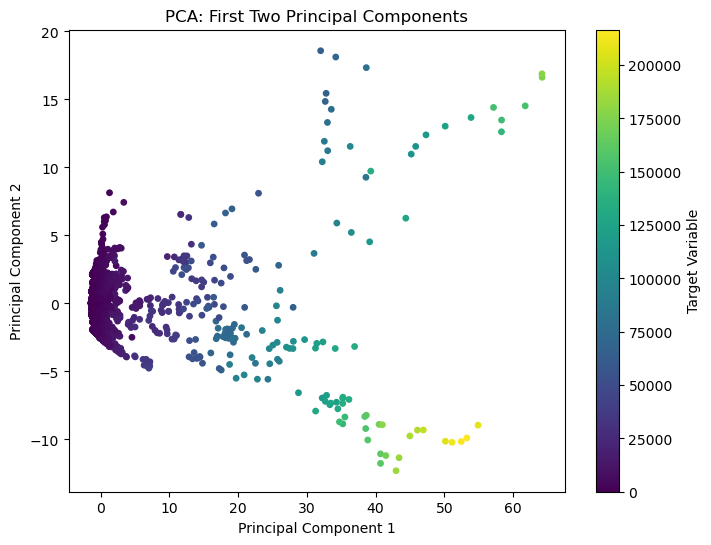

In [2]:
# 1. Principal Component Analysis (PCA)
# =============================
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
X_pca = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio by PCA components:", pca.explained_variance_ratio_)
print("Cumulative Explained Variance:", np.cumsum(pca.explained_variance_ratio_))

# Visualize PCA components
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=15)
plt.title('PCA: First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Target Variable')
plt.show()

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


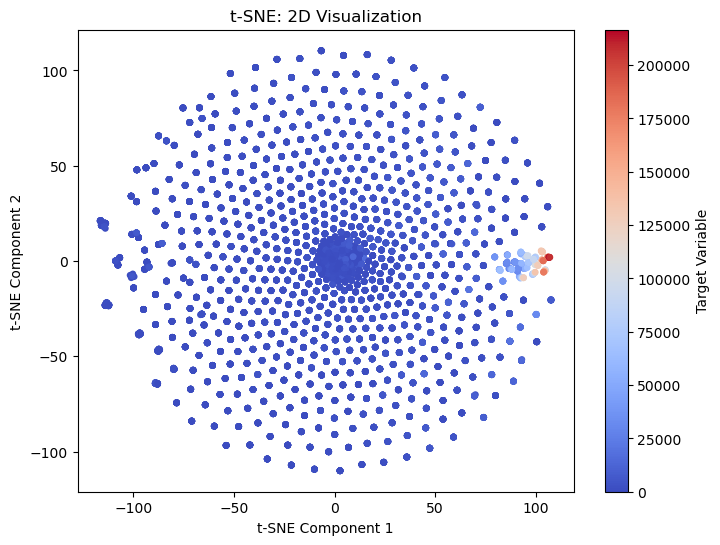

In [6]:
# 2. t-Distributed Stochastic Neighbor Embedding (t-SNE)
# =============================
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Visualize t-SNE
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', s=15)
plt.title('t-SNE: 2D Visualization')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='Target Variable')
plt.show()

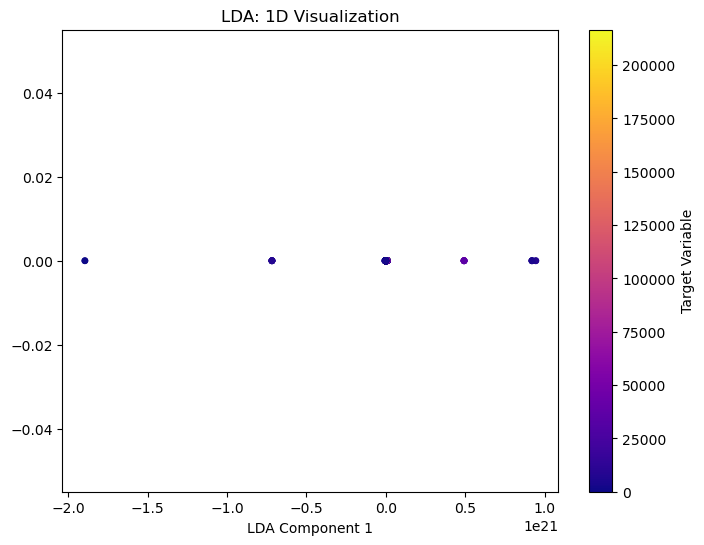

In [7]:
# 3. Linear Discriminant Analysis (LDA)
# =============================
# Note: LDA is supervised; the number of components ≤ number of classes - 1
lda = LDA(n_components=1)  # Reduce to 1 dimension
X_lda = lda.fit_transform(X_scaled, y)

# Visualize LDA
plt.figure(figsize=(8, 6))
plt.scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='plasma', s=15)
plt.title('LDA: 1D Visualization')
plt.xlabel('LDA Component 1')
plt.colorbar(label='Target Variable')
plt.show()

In [8]:
# 4. Feature Agglomeration
# =============================
fa = FeatureAgglomeration(n_clusters=5)  # Group features into 5 clusters
X_fa = fa.fit_transform(X_scaled)

print("\nFeature Agglomeration Reduced Shape:", X_fa.shape)


Feature Agglomeration Reduced Shape: (9017, 5)
